In [1]:
import os
import pandas as pd
import json
import sqlite3
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math 
import random 
import igraph as ig
import networkx as nx
from math import log
import pickle
import gzip
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import copy
from functools import partial
from platform import system
import sys 
from pathlib import Path 

import 

In [19]:

ROOT = Path(__file__).resolve().parents[1] if "__file__" in globals() else Path.cwd().parents[0]
SRC  = ROOT / "src"
DATA = ROOT / "data"
FIGS = ROOT / "figures"

print("Project root:", ROOT)
print("Data folder:", DATA)
print("Figures folder:", FIGS)

sys.path.insert(0, str(SRC))
from utils import * 
from label_colors import *
import label_colors
from echo_chamber_matrix import *


csvdf2 = pd.read_csv(DATA / 'Subreddit_Tags.csv', sep=';', index_col=False)


DizValTag = {} 

for i in range(len(csvdf2)) : 
    nome=csvdf2['subreddit'][i]
    n = 0
    for col in csvdf2.columns : 
        if col != 'subreddit' : 
            if csvdf2[col][i] != 0 : 
                n += 1 
    for col in csvdf2.columns : 
        if col != 'subreddit' : 
            if csvdf2[col][i] == 1 : 
                DizValTag[col+"_"+nome] = (1.0/n)
print(len(DizValTag)) 
print(DizValTag)



# === update the module's globals ===
label_colors.csvdf2 = csvdf2
label_colors.DizValTag = DizValTag
print("✅ Updated label_colors module globals")

Project root: /Users/Daniele/Downloads/PolitoSphere Finale (Postzip)
Data folder: /Users/Daniele/Downloads/PolitoSphere Finale (Postzip)/data
Figures folder: /Users/Daniele/Downloads/PolitoSphere Finale (Postzip)/figures
715
{'Dem_2012Elections': 0.5, 'Cons_2012Elections': 0.5, 'Dem_2016Elections': 0.5, 'Cons_2016Elections': 0.5, 'Dem_2016_elections': 0.5, 'Cons_2016_elections': 0.5, 'Lib_2ALiberals': 0.5, 'Gun_2ALiberals': 0.5, 'Politic_AOC': 0.5, 'Dem_AOC': 0.5, 'SocialJustice_Abortiondebate': 1.0, 'Geop_ActiveMeasures': 0.5, 'News_ActiveMeasures': 0.5, 'SocialJustice_AgainstHateSubreddits': 1.0, 'Ban_AgainstTheChimpire': 1.0, 'Econ_Agorism': 1.0, 'Canada_Albertapolitics': 1.0, 'Dem_AlexandriaOcasio': 1.0, 'Ban_AltRightChristian': 1.0, 'Politic_AmalaNetwork': 1.0, 'Politic_AmericanPolitics': 1.0, 'Far-Right_AnCap101': 1.0, 'Far-Left_Anarchism': 1.0, 'Far-Left_AnarchismOnline': 1.0, 'News_AnarchistNews': 0.5, 'Far-Left_AnarchistNews': 0.5, 'Far-Left_Anarcho_Capitalism': 1.0, 'Far-Left

In [6]:
interaction_community_ex = pickle.load(open(DATA / 'interaction_community_ex.pkl', 'rb'))
information_community_ex = pickle.load(open(DATA / 'information_community_ex.pkl', 'rb'))

#user_normalization_dict.json.gz da github_output/
with gzip.open(DATA / "user_normalization_dict.json.gz", "rt", encoding="utf-8") as f:
    user_normalization_dict = json.load(f)

#user_normalization_dict[0] # "0" -- 2013
print("keys", user_normalization_dict.keys())
print("User normalization dict loaded with", len(user_normalization_dict["0"]), "users.")


keys dict_keys(['0', '1', '2', '3', '4'])
User normalization dict loaded with 387691 users.


Subreddit Overlap

In [7]:

#2013
list_matrix_ec = {}
for j in range(len(interaction_community_ex)):
    list_matrix_ec[j] = {}
    for k in range(len(information_community_ex)):
        list_matrix_ec[j][k] = {}
        weight_list = calculate_overlap_list(interaction_community_ex[j], information_community_ex[k])
        list_matrix_ec[j][k] = weight_list

#list_matrix_ec

User-Weight

In [ ]:
user_data_2013 = user_normalization_dict["0"]
User_list_matrix_ec = assign_users_to_blocks(list_matrix_ec, user_data_2013)
print("OK: 2013")

OK: 2013


In [10]:
set_unico_matrice_totale = set()
numero_totale_utenti = 0
for i in User_list_matrix_ec:
    for j in User_list_matrix_ec[i]:
        set_unico_matrice_totale.update(User_list_matrix_ec[i][j])
        numero_totale_utenti += len(User_list_matrix_ec[i][j])
print("#Unique users in EC matrix:", len(set_unico_matrice_totale))
print("Unique users in EC matrix:", numero_totale_utenti)

#Unique users in EC matrix: 157399
Unique users in EC matrix: 268689


In [11]:

w_User_list_matrix_ec = {}  

w_User_list_matrix_ec[2013] = {
    i: {j: 0 for j in inner_dict.keys()} for i, inner_dict in list_matrix_ec.items()
}

for i in range(len(list_matrix_ec)):
    for j in range(len(list_matrix_ec[i])):
        w_User_list_matrix_ec[2013][i][j] = len(User_list_matrix_ec[i][j])
w_User_list_matrix_ec[2013] = np.array([
    np.array(list(w_User_list_matrix_ec[2013][i].values()))
    for i in range(len(w_User_list_matrix_ec[2013]))
])
print("Shape:", w_User_list_matrix_ec[2013].shape)
total_weight_2013 = np.sum(w_User_list_matrix_ec[2013])
print("Total weight EC matrix 2013:", total_weight_2013)
print("Example block (5x5):\n", w_User_list_matrix_ec[2013][:5, :5])

Shape: (7, 9)
Total weight EC matrix 2013: 268689
Example block (5x5):
 [[    0     0    87     0     0]
 [  326     0   457     0   827]
 [ 6371     0 37064     0     0]
 [    0   385     0     0     0]
 [ 2306   627   702   919     0]]


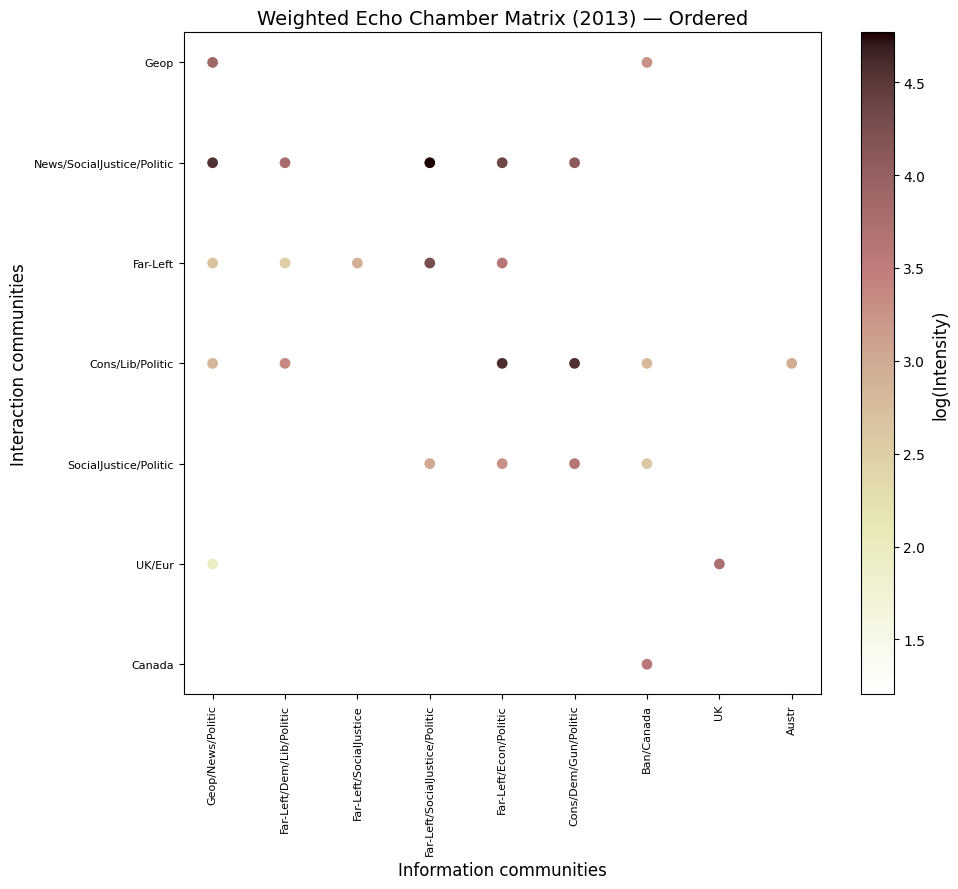

In [ ]:


community_labels_interaction = {}
community_labels_information = {}
for comm_id, nodes in interaction_community_ex.items():
    label = Label_from_list(nodes, DizValTag)
    community_labels_interaction[comm_id] = label

for comm_id, nodes in information_community_ex.items():
    label = Label_from_list(nodes, DizValTag)
    community_labels_information[comm_id] = label

nomi_userbased = [community_labels_interaction[i] for i in range(len(community_labels_interaction))]
nomi_domainbased = [community_labels_information[j] for j in range(len(community_labels_information))]


W = w_User_list_matrix_ec[2013].astype(float)

W_log = np.log10(W + 1)  # aggiungo +1 per evitare log(0)

ordine = [
    "Geop", "News", "Far-Left", "Econ", "PolTalk", "Politic", "Dem", "Lib",
    "Cons", "Gun", "Far-Right", "Ban", "SocialJustice", "UK", "Eur", "Canada", "Austr"
]

#mapping

labels_y_ord, colors_y_ord = ordina_legenda(nomi_userbased, [None]*len(nomi_userbased), ordine)
labels_x_ord, colors_x_ord = ordina_legenda(nomi_domainbased, [None]*len(nomi_domainbased), ordine)

index_y_map = {lab: i for i, lab in enumerate(nomi_userbased)}
index_x_map = {lab: j for j, lab in enumerate(nomi_domainbased)}

sort_y = [index_y_map[lab] for lab in labels_y_ord if lab in index_y_map]
sort_x = [index_x_map[lab] for lab in labels_x_ord if lab in index_x_map]

W_ord = W[np.ix_(sort_y, sort_x)]
W_log = np.log10(W_ord + 1)

plt.figure(figsize=(10, 9))

xs, ys = np.meshgrid(np.arange(W_ord.shape[1]), np.arange(W_ord.shape[0]))
xs, ys = xs.flatten(), ys.flatten()
vals = W_log.flatten()

mask = vals > 0
vmin, vmax = np.min(vals[mask]), np.max(vals[mask])

sc = plt.scatter(xs[mask], ys[mask], s=60, c=vals[mask],
                 cmap="pink_r", marker="o", vmin=vmin, vmax=vmax, edgecolor='none')

cbar = plt.colorbar(sc)
cbar.set_label("log(Intensity)", fontsize=12)

plt.xticks(range(W_ord.shape[1]), labels_x_ord, rotation=90, fontsize=8)
plt.yticks(range(W_ord.shape[0]), labels_y_ord, fontsize=8)
plt.xlabel("Information communities", fontsize=12)
plt.ylabel("Interaction communities", fontsize=12)
plt.title("Weighted Echo Chamber Matrix (2013) — Ordered", fontsize=14)
plt.gca().invert_yaxis()

plt.tight_layout()
#plt.savefig(FIGS / "Weighted_Echo_Chamber_Matrix_2013_Ordered.png", dpi=300)
plt.show()


